# Uncertainty Quantification in Regression


This notebook introduces uncertainty quantification in deep learning for regression problems. <br>
The notebook is part of the HAICON 2026 Uncertainty Quantification Workshop.

## Learning Goals
- Understand **aleatoric** vs **epistemic** uncertainty in classification tasks
- Evaluate the calibration of uncertainty estimates
- Compare multiple UQ approaches for aleatoric and epistemic uncertainty quantification

## Methods Covered
The notebook introduces and covers the following approaches.

| Method | Aleatoric | Epistemic |
|--------|:---------:|:---------:|
| Plain Softmax CNN | ✅ | ❌ |
| MC Dropout | ✅ | ✅ |
| Deep Ensembles | ✅ | ✅ |
---


# Uncertainty Quantification in MNIST Classification
In this notebook we use the well-kown **MNIST** as a
concrete testbed for uncertainty quantification. 

The notebook is split into **two parts**:

**Part 1: Standard MNIST** (Sections 1–7) 

**Part 2: Rotated MNIST as Out-of-Distribution (OOD)** (Sections 8–13)  

---
## 1  Setup

In [76]:
# ─── Colab install (uncomment if needed) ──────────────────────────────────────
# !pip install torch torchvision scikit-learn matplotlib scipy -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.special import softmax as scipy_softmax
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Colour palette (workshop-wide)
BLUE   = '#4C72B0'; ORANGE = '#DD8452'; GREEN  = '#55A868'
RED    = '#C44E52'; PURPLE = '#8172B2'; GRAY   = '#BBBBBB'
TEAL   = '#00A9A5'; PINK   = '#DA8BC3'; DARK   = '#151618'

plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False,
                     'font.size': 11})

print(f'PyTorch {torch.__version__}  |  Device: {device}  |  Seed {SEED}')

PyTorch 2.7.0+cu126  |  Device: cuda  |  Seed 42


---
# Part 1: Standard MNIST

---
## 1  Dataset

MNIST contains 70,000 greyscale images (28 × 28 pixels) of handwritten
digits 0–9. We use **8,000 training** images and **2,000 test** images.

Images are normalised to zero mean / unit variance using the standard
MNIST statistics (mean = 0.1307, std = 0.3081).  

#### Load Data

In [ ]:
# ─── Load MNIST ───────────────────────────────────────────────────────────────
transform = T.Compose([T.ToTensor(),
                        T.Normalize((0.1307,), (0.3081,))])

train_full = torchvision.datasets.MNIST(
    root='./data', train=True,  download=True, transform=transform)
test_full  = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

N_TRAIN, N_TEST = 8_000, 2_000
rng = np.random.default_rng(SEED)
train_idx = rng.choice(len(train_full), N_TRAIN, replace=False)
test_idx  = rng.choice(len(test_full),  N_TEST,  replace=False)

train_set = Subset(train_full, train_idx)
test_set  = Subset(test_full,  test_idx)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=0)

# Collect full test tensors once — used throughout the notebook
X_test = torch.cat([xb for xb, _ in test_loader])   # [N, 1, 28, 28]
y_test = torch.cat([yb for _, yb in test_loader])    # [N]
y_np   = y_test.numpy()

print(f'Train: {N_TRAIN:,}  |  Test: {N_TEST:,}')

Train: 8,000  |  Test: 2,000


#### Print Example Data

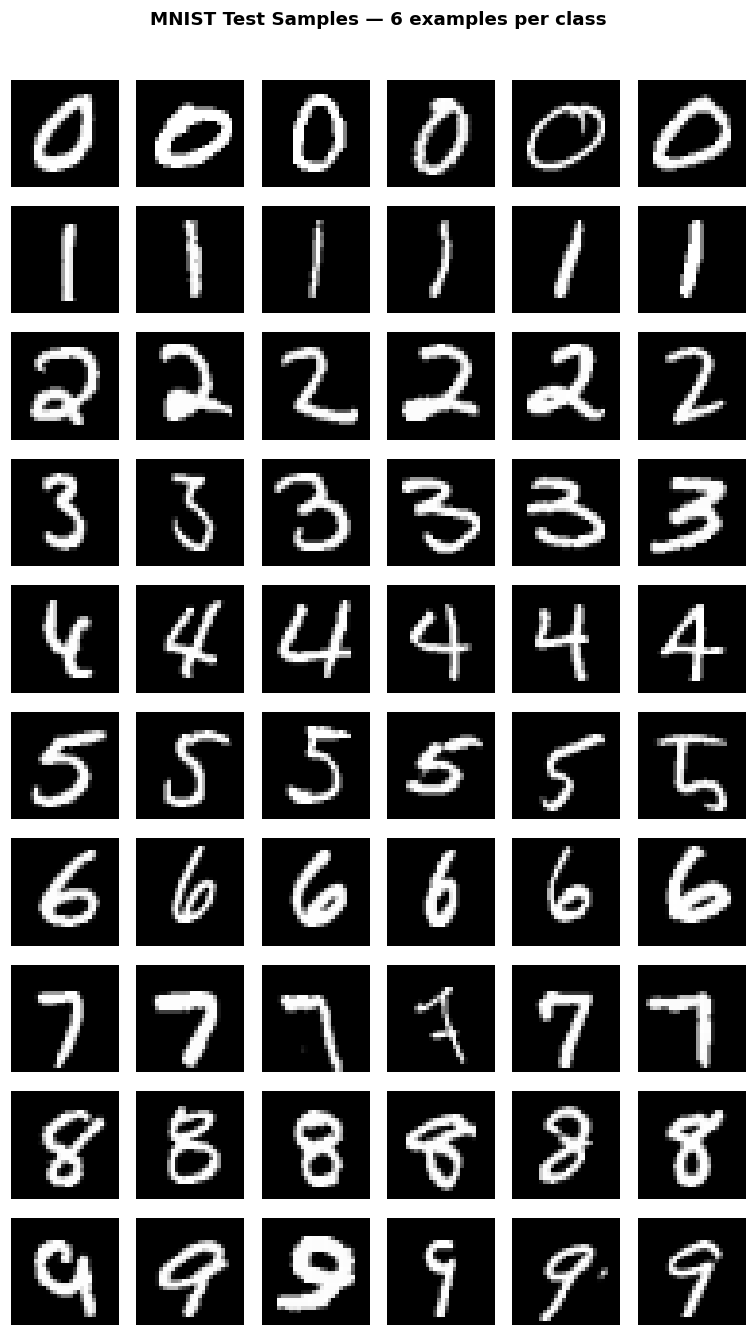

In [78]:


# ─── Show sample images ───────────────────────────────────────────────────────
fig, axes = plt.subplots(10, 6, figsize=(7, 12))
for cls in range(10):
    idxs = (y_test == cls).nonzero(as_tuple=True)[0][:6]
    for col, idx in enumerate(idxs):
        axes[cls, col].imshow(X_test[idx].squeeze(), cmap='gray')
        axes[cls, col].axis('off')
    axes[cls, 0].set_ylabel(f"'{cls}'", rotation=0, labelpad=20,
                              fontsize=10, fontweight='bold', va='center')
plt.suptitle('MNIST Test Samples — 6 examples per class',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2  Architecture & Training

All UQ methods share the **same lightweight CNN** backbone — ensuring that
any differences in uncertainty quality come from the UQ method, not from
architecture differences.

```
Conv(1→16, 3×3) → ReLU
Conv(16→32, 3×3) → ReLU → MaxPool(2×2)     # output: 32 × 14 × 14
Flatten → Linear(6272→128) → ReLU
[Dropout(p)]                                # only used for MC Dropout
Linear(128→10)                              # logits
```

- **Baseline**: `dropout = 0.0`
- **MC Dropout**: `dropout = 0.3`  
- **Ensemble**: 3 independent runs with different seeds, `dropout = 0.0`

Total parameters: ~0.8 M (feasible on CPU).

#### Model Implementation and Helper Functions

In [79]:
# ─── Lightweight CNN ──────────────────────────────────────────────────────────
class MnistCNN(nn.Module):
    """Compact LeNet-style CNN shared by all UQ methods."""
    def __init__(self, dropout: float = 0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                # 28×28 → 14×14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


print(f'Parameters: {sum(p.numel() for p in MnistCNN().parameters()):,}')


# ─── Training loop ────────────────────────────────────────────────────────────
def train_model(model, n_epochs=10, lr=0.005):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    hist = []
    for ep in range(n_epochs):
        print(f"Epoch [{ep+1}/{n_epochs}] ...       ", end="\r")
        model.train()
        ep_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = nn.functional.cross_entropy(model(xb), yb)
            loss.backward()
            opt.step()
            ep_loss += 1

        hist.append(ep_loss)
    acc = (get_probs(model, X_test).argmax(-1) == y_np).mean()
    print(f'  Test accuracy: {acc*100:.1f}%')
    return acc


# ─── Inference helpers ────────────────────────────────────────────────────────
@torch.no_grad()
def get_probs(model, X, bs=256):
    """Softmax probabilities [N, 10] — model in eval mode."""
    model.eval()
    return np.concatenate([
        F.softmax(model(X[i:i+bs].to(device)), dim=-1).cpu().numpy()
        for i in range(0, len(X), bs)
    ])

@torch.no_grad()
def get_logits(model, X, bs=256):
    """Raw logits [N, 10] as CPU tensor."""
    model.eval()
    return torch.cat([
        model(X[i:i+bs].to(device)).cpu()
        for i in range(0, len(X), bs)
    ])

def entropy(p):
    """Predictive entropy for probability array [..., C]."""
    return -(p * np.log(p + 1e-9)).sum(-1)

Parameters: 809,034


#### Model Training

In [80]:
# ─── Train baseline classifier ────────────────────────────────────────────────
print('Training baseline softmax classifier...')
clf = MnistCNN(dropout=0.0).to(device)
train_model(clf, n_epochs=15);

Training baseline softmax classifier...
  Test accuracy: 97.2%  


---
## 3  The Overconfidence Problem

Accuracy tells us *how often* the model is right, but says nothing about
how confident it is when it is wrong.  A well-calibrated classifier should
satisfy:

$$P(\hat{y} = y \mid \max_k\,p_k = c) = c$$

Intuitively: **when the model says "90% confident", it should be
correct about 90% of the time.**

We assess this with two complementary tools:

1. **Reliability diagram**: plots fraction-correct vs predicted confidence
   in confidence bins. A perfectly calibrated model lies on the diagonal.
2. **Expected Calibration Error (ECE)**: the weighted average gap between
   confidence and accuracy across bins.

$$\mathrm{ECE} = \sum_{b=1}^{B} \frac{|\mathcal{B}_b|}{N}
  \left|\mathrm{acc}(\mathcal{B}_b) - \overline{\mathrm{conf}}(\mathcal{B}_b)\right|$$


**Important:** When the accuracy is very high (i.e. most samples are correct) calibration plots can be misleading. 

Test accuracy:       97.2%
Mean max-confidence: 0.991
Calibration gap:     +0.020  (positive = overconfident)


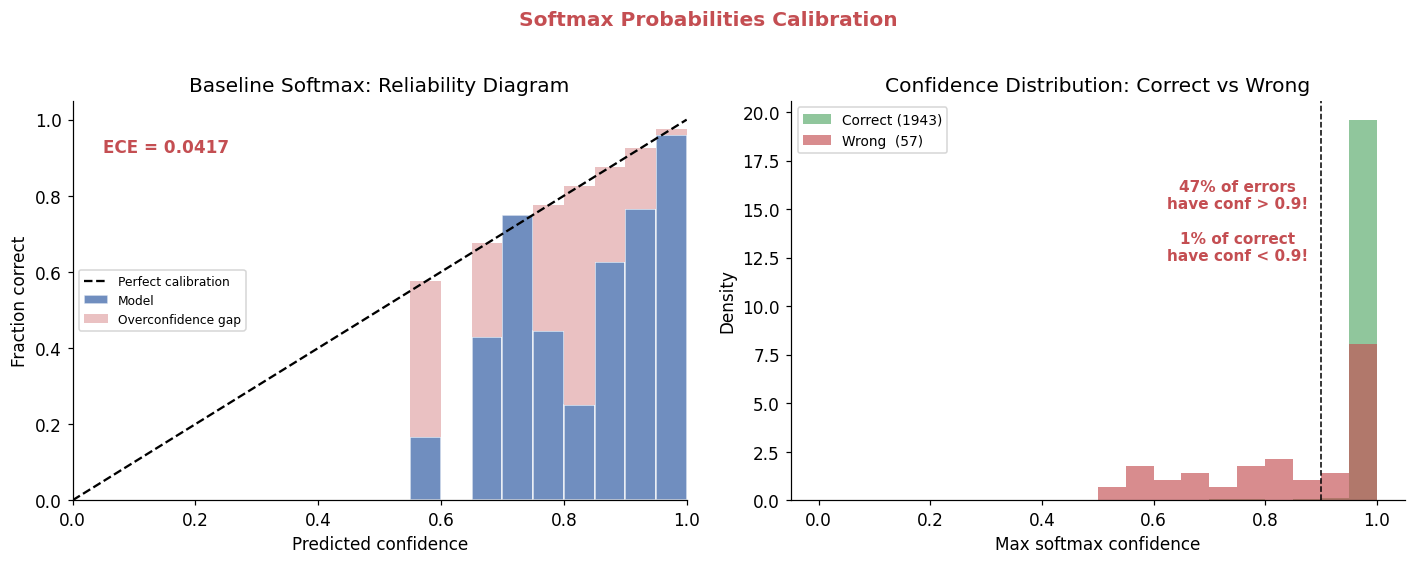

In [81]:
# ─── Reliability diagram helper ───────────────────────────────────────────────

num_bins = 20
def reliability_diagram(ax, probs, labels, title='', n_bins=num_bins, color=BLUE):
    """Plots reliability diagram; returns ECE."""
    conf    = probs.max(-1)
    correct = (probs.argmax(-1) == labels).astype(float)
    edges   = np.linspace(0, 1, n_bins + 1)
    bin_c, acc_b, cnt_b = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf >= lo) & (conf < hi)
        if mask.sum() > 5:
            bin_c.append((lo + hi) / 2)
            acc_b.append(correct[mask].mean())
            cnt_b.append(mask.sum())
    bin_c, acc_b, cnt_b = map(np.array, [bin_c, acc_b, cnt_b])
    ece = (cnt_b * np.abs(acc_b - bin_c)).sum() / cnt_b.sum()

    ax.bar(bin_c, acc_b, width=1./n_bins, alpha=0.8, color=color,
            edgecolor='white', label='Model')
    ax.bar(bin_c, np.maximum(bin_c - acc_b, 0), width=1./n_bins,
            bottom=acc_b, alpha=0.35, color=RED, label='Overconfidence gap')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
    ax.text(0.05, 0.87, f'ECE = {ece:.4f}', transform=ax.transAxes,
             fontsize=11, fontweight='bold',
             color=(RED if ece > 0.03 else GREEN))
    ax.set(xlabel='Predicted confidence', ylabel='Fraction correct',
            title=title, xlim=(0, 1), ylim=(0, 1.05))
    ax.legend(fontsize=8)
    return ece


# ─── Compute baseline predictions ─────────────────────────────────────────────
probs_base   = get_probs(clf, X_test)
correct_mask = probs_base.argmax(-1) == y_np

print(f'Test accuracy:       {correct_mask.mean()*100:.1f}%')
print(f'Mean max-confidence: {probs_base.max(-1).mean():.3f}')
print(f'Calibration gap:     {probs_base.max(-1).mean() - correct_mask.mean():+.3f}'
      f'  (positive = overconfident)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reliability diagram
reliability_diagram(axes[0], probs_base, y_np,
                    title='Baseline Softmax: Reliability Diagram',
                    color=BLUE)

# Confidence histogram: correct vs wrong
conf_all     = probs_base.max(-1)
conf_correct = conf_all[ correct_mask]
conf_wrong   = conf_all[~correct_mask]
bins = np.linspace(0, 1, num_bins+1)
axes[1].hist(conf_correct, bins=bins, color=GREEN, alpha=0.65,
              label=f'Correct ({correct_mask.sum()})', density=True)
axes[1].hist(conf_wrong,   bins=bins, color=RED,   alpha=0.65,
              label=f'Wrong  ({(~correct_mask).sum()})', density=True)
axes[1].axvline(0.9, color='black', ls='--', lw=1)
frac_hc_wrong = (conf_wrong > 0.9).mean()
frac_lc_correct = (conf_correct < 0.9).mean()
axes[1].set(xlabel='Max softmax confidence', ylabel='Density',
             title='Confidence Distribution: Correct vs Wrong')
axes[1].legend(fontsize=9)
# Annotate after axis limits are known
ylim_top = axes[1].get_ylim()[1]
axes[1].text(0.75, ylim_top * 0.60,
              f'{frac_hc_wrong*100:.0f}% of errors\nhave conf > 0.9!\n\n{frac_lc_correct*100:.0f}% of correct\nhave conf < 0.9!',
              color=RED, fontsize=10, fontweight='bold', ha='center')

plt.suptitle('Softmax Probabilities Calibration',
             color=RED, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

High-confidence errors (conf > 85%): 30 total — showing 10


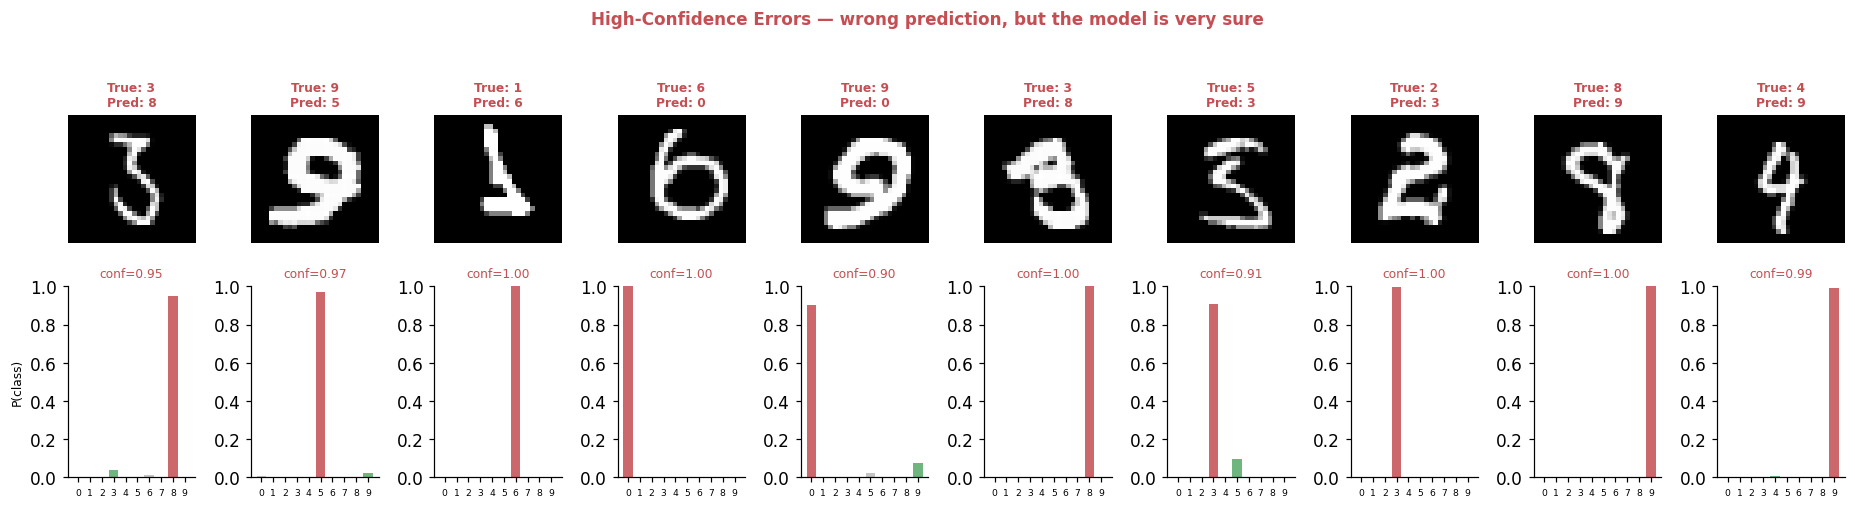

In [82]:
# ─── Show individual high-confidence errors ───────────────────────────────────
# These are the most dangerous failure mode: wrong, but very sure.
preds_base = probs_base.argmax(-1)
wrong_hc   = np.where((preds_base != y_np) & (probs_base.max(-1) > 0.85))[0]
n_show     = min(10, len(wrong_hc))
print(f'High-confidence errors (conf > 85%): {len(wrong_hc)} total — showing {n_show}')

if n_show > 0:
    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.7, 4.5))
    if n_show == 1: axes = axes.reshape(2, 1)
    for col, i in enumerate(wrong_hc[:n_show]):
        axes[0, col].imshow(X_test[i].squeeze(), cmap='gray'); axes[0, col].axis('off')
        axes[0, col].set_title(f'True: {y_np[i]}\nPred: {preds_base[i]}',
                                fontsize=8, color=RED, fontweight='bold')
        axes[1, col].bar(range(10), probs_base[i],
                          color=[GREEN if c==y_np[i] else RED if c==preds_base[i] else GRAY
                                 for c in range(10)], alpha=0.85)
        axes[1, col].set_xticks(range(10)); axes[1, col].set_xticklabels(range(10), fontsize=6)
        axes[1, col].set_ylim(0, 1)
        axes[1, col].set_title(f'conf={probs_base[i].max():.2f}', fontsize=8, color=RED)
        if col == 0: axes[1, col].set_ylabel('P(class)', fontsize=8)
    plt.suptitle('High-Confidence Errors — wrong prediction, but the model is very sure',
                  fontsize=11, fontweight='bold', y=1.02, color=RED)
    plt.tight_layout()
    plt.show()

---
## 5  MC Dropout — Bayesian Approximation

Temperature scaling fixes the *scale* of confidence, but gives no
information about *where* the model is uncertain. **MC Dropout** provides
a richer signal: keeping dropout active at test time turns each forward
pass into a sample from an approximate posterior over weights.

With $T$ stochastic passes we obtain a distribution over predictions:

$$\bar{p} = \frac{1}{T}\sum_{t=1}^T p^{(t)}(y|x)$$

From this we decompose uncertainty:

| Quantity | Formula | Meaning |
|----------|---------|----------|
| **Total (predictive entropy)** | $H[y|x]$ | Model unsure about the answer |
| **Epistemic (mutual info)** | $I = H[\bar{p}] - \mathbb{E}_t[H[p^{(t)}]]$ | Reducible — model hasn't seen this kind of input |
| **Aleatoric** | $H - I$ | Irreducible — inherent digit ambiguity |

**MC Dropout is cheap**: a single model, just $T$ forward passes at test
time. Training cost is identical to the baseline.

In [83]:
# ─── Train MC Dropout model ───────────────────────────────────────────────────
print('Training MC Dropout model (dropout=0.3)...')
mc_clf = MnistCNN(dropout=0.2).to(device)
train_model(mc_clf, n_epochs=15)


# ─── MC Dropout prediction ────────────────────────────────────────────────────
def mc_predict(model, X, T=50, bs=256):
    """
    T stochastic forward passes (dropout active).
    Returns: mean_p [N,10], pred_entropy [N], mutual_info [N]
    """
    model.train()   # keeps dropout ON
    all_p = []
    with torch.no_grad():
        for _ in range(T):
            s = np.concatenate([
                F.softmax(model(X[i:i+bs].to(device)), dim=-1).cpu().numpy()
                for i in range(0, len(X), bs)
            ])
            all_p.append(s)
    P        = np.stack(all_p)           # [T, N, 10]
    mean_p   = P.mean(0)                 # [N, 10]
    pred_ent = entropy(mean_p)           # total uncertainty
    mean_ent = entropy(P).mean(0)        # aleatoric proxy
    mi       = pred_ent - mean_ent       # epistemic
    return mean_p, pred_ent, mi


MC_T = 50
print(f'Running {MC_T} MC passes on test set...')
p_mc, ent_mc, mi_mc = mc_predict(mc_clf, X_test, T=MC_T)
ale_mc = ent_mc - mi_mc

print(f'\nMC Dropout accuracy:            {(p_mc.argmax(-1)==y_np).mean()*100:.1f}%')
print(f'Mean entropy on CORRECT preds:  {ent_mc[p_mc.argmax(-1)==y_np].mean():.4f}')
print(f'Mean entropy on WRONG   preds:  {ent_mc[p_mc.argmax(-1)!=y_np].mean():.4f}')
print('→ Entropy is higher on wrong predictions ✓')

Training MC Dropout model (dropout=0.3)...
  Test accuracy: 97.8%  
Running 50 MC passes on test set...

MC Dropout accuracy:            97.8%
Mean entropy on CORRECT preds:  0.0385
Mean entropy on WRONG   preds:  0.5308
→ Entropy is higher on wrong predictions ✓


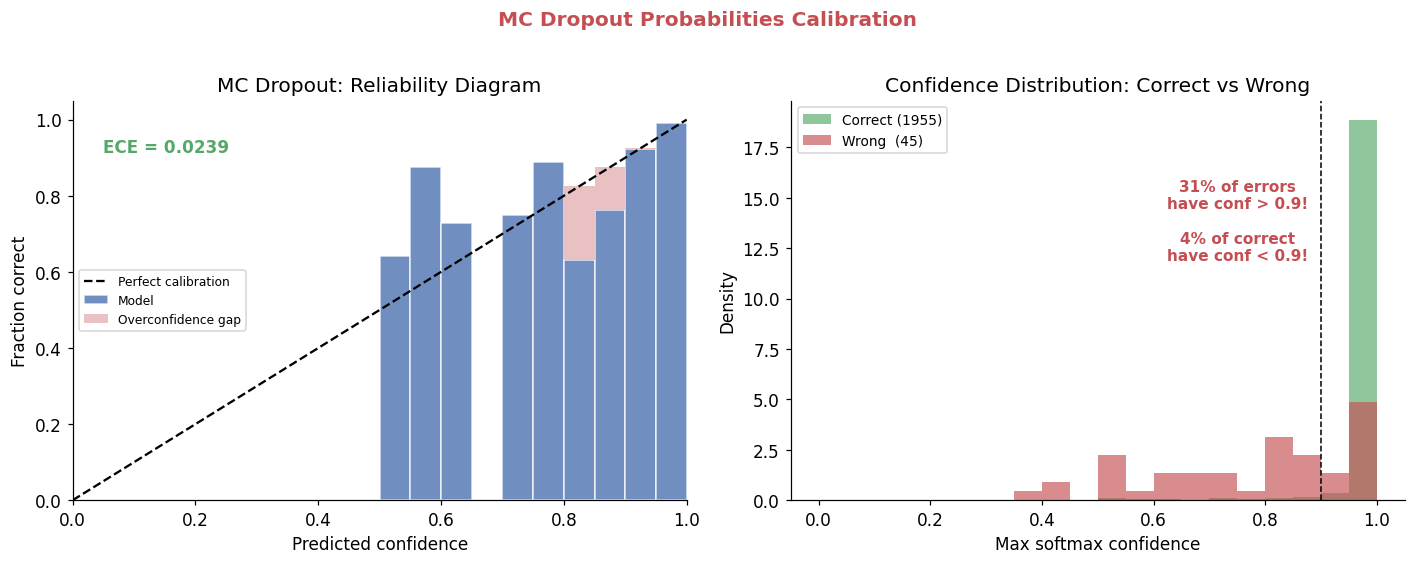

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reliability diagram
reliability_diagram(axes[0], p_mc, y_np,
                    title='MC Dropout: Reliability Diagram',
                    color=BLUE)

correct_mask = p_mc.argmax(-1) == y_np

# Confidence histogram: correct vs wrong
conf_all     = p_mc.max(-1)
conf_correct = conf_all[ correct_mask]
conf_wrong   = conf_all[~correct_mask]
bins = np.linspace(0, 1, num_bins+1)
axes[1].hist(conf_correct, bins=bins, color=GREEN, alpha=0.65,
              label=f'Correct ({correct_mask.sum()})', density=True)
axes[1].hist(conf_wrong,   bins=bins, color=RED,   alpha=0.65,
              label=f'Wrong  ({(~correct_mask).sum()})', density=True)
axes[1].axvline(0.9, color='black', ls='--', lw=1)
frac_hc_wrong = (conf_wrong > 0.9).mean()
frac_lc_correct = (conf_correct < 0.9).mean()

axes[1].set(xlabel='Max softmax confidence', ylabel='Density',
             title='Confidence Distribution: Correct vs Wrong')
axes[1].legend(fontsize=9)
# Annotate after axis limits are known
ylim_top = axes[1].get_ylim()[1]
axes[1].text(0.75, ylim_top * 0.60,
              f'{frac_hc_wrong*100:.0f}% of errors\nhave conf > 0.9!\n\n{frac_lc_correct*100:.0f}% of correct\nhave conf < 0.9!',
              color=RED, fontsize=10, fontweight='bold', ha='center')

plt.suptitle('MC Dropout Probabilities Calibration',
             color=RED, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6  Deep Ensemble

Instead of one model with dropout, we train **M independent models** from
different random seeds. Their *disagreement* on any given input is a direct
measure of epistemic uncertainty.

$$\bar{p}^\mathrm{ens} = \frac{1}{M}\sum_{m=1}^M p_m(y|x)$$

Mutual information (MI) still decomposes total into epistemic uncertainty
exactly as for MC Dropout — just with model index instead of dropout sample.

**Why ensembles work well:**
- Diversity comes from different loss-landscape basins, not just stochastic
  forward passes  
- No special training trick required  
- Often the strongest UQ baseline in practice

**The cost:** M× training and inference time. We use M = 5.

In [90]:
# ─── Train ensemble ───────────────────────────────────────────────────────────
N_ENS = 5
ens_models = []
for i in range(N_ENS):
    print(f'Ensemble member {i+1}/{N_ENS}...')
    torch.manual_seed(SEED + i * 137)
    m = MnistCNN(dropout=0.0).to(device)
    train_model(m, n_epochs=15)
    ens_models.append(m)


def ens_predict(X, bs=256):
    """Average predictions across ensemble. Returns mean_p, entropy, MI."""
    P        = np.stack([get_probs(m, X, bs) for m in ens_models])  # [M,N,10]
    mean_p   = P.mean(0)
    pred_ent = entropy(mean_p)
    mean_ent = entropy(P).mean(0)
    mi       = pred_ent - mean_ent
    return mean_p, pred_ent, mi


print('\nRunning ensemble on test set...')
p_ens, ent_ens, mi_ens = ens_predict(X_test)
print(f'Ensemble accuracy: {(p_ens.argmax(-1)==y_np).mean()*100:.1f}%')

Ensemble member 1/5...
  Test accuracy: 97.5%  
Ensemble member 2/5...
  Test accuracy: 98.0%  
Ensemble member 3/5...
  Test accuracy: 97.8%  
Ensemble member 4/5...
  Test accuracy: 97.2%  
Ensemble member 5/5...
  Test accuracy: 97.8%  

Running ensemble on test set...
Ensemble accuracy: 98.2%


---
## 7  Comparing All Methods on Clean MNIST

Before introducing any distribution shift we benchmark all three approaches
on standard test data along three axes:

1. **Calibration** (reliability diagram + ECE)
2. **Error detection** — does high uncertainty predict wrong predictions?
   We measure this with AUROC of uncertainty score vs. misclassification label.
3. **Uncertainty histograms** — does the uncertainty distribution look sensible?

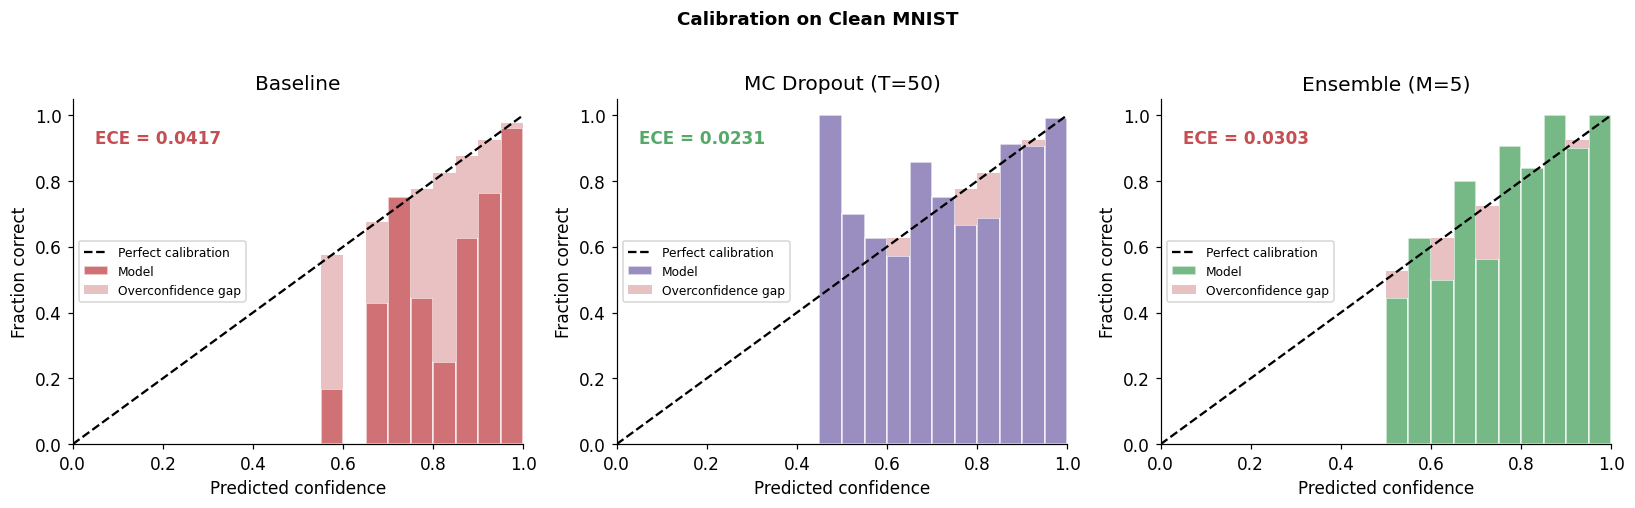

ECE summary (lower = better):
  Baseline                  0.0417  ████████████
  MC Dropout T=50           0.0231  ██████
  Ensemble M=5              0.0303  █████████


In [89]:
# ─── Calibration comparison ─────────────────────────────────────────────────
p_base_e = get_probs(clf,    X_test)
p_mc_e,  _, _ = mc_predict(mc_clf, X_test, T=MC_T)
p_ens_e, _, _ = ens_predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ece_b   = reliability_diagram(axes[0], p_base_e, y_np, 'Baseline',          color=RED)
ece_mc  = reliability_diagram(axes[1], p_mc_e,   y_np, f'MC Dropout (T={MC_T})', color=PURPLE)
ece_ens = reliability_diagram(axes[2], p_ens_e,  y_np, f'Ensemble (M={N_ENS})',  color=GREEN)

plt.suptitle('Calibration on Clean MNIST', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
---
# Part 2 — Rotated MNIST as a Controlled OOD Benchmark

---

In Part 1 we evaluated UQ on clean, in-distribution data.
Now we ask a harder question:

> *What happens when the test data **systematically drifts** away from the
> training distribution?*

We use **rotation** as a controlled OOD knob.  The model was trained on
upright (0°) digits only.  By rotating test images by angle $\theta$ we
create a gradient of distribution shift — from familiar (0°) to strongly
out-of-distribution (90°–180°).

This setup lets us answer:
- Does confidence correctly decrease as inputs become more foreign?
- Which UQ method best *detects* OOD inputs at each severity level?
- How do the individual examples look — when does the model first fail?

---
## 8  The Rotation Function — Background Preservation

After normalisation, MNIST background pixels have a value of **≈ −0.42**,
not zero. PyTorch's `rotate` fills newly-introduced corner pixels with
`fill=0` by default, which is *brighter than the background* — creating
an artefact that looks like a bright border and will confuse the model
for reasons unrelated to the rotation itself.

**Fix:** shift the image so that background = 0 before rotating,
then shift back afterwards:

```
x_shifted = x − min(x)      # background becomes exactly 0
rotated   = rotate(x_shifted, fill=0)   # new pixels = 0 = background  ✓
output    = rotated + min(x)            # restore original scale
```

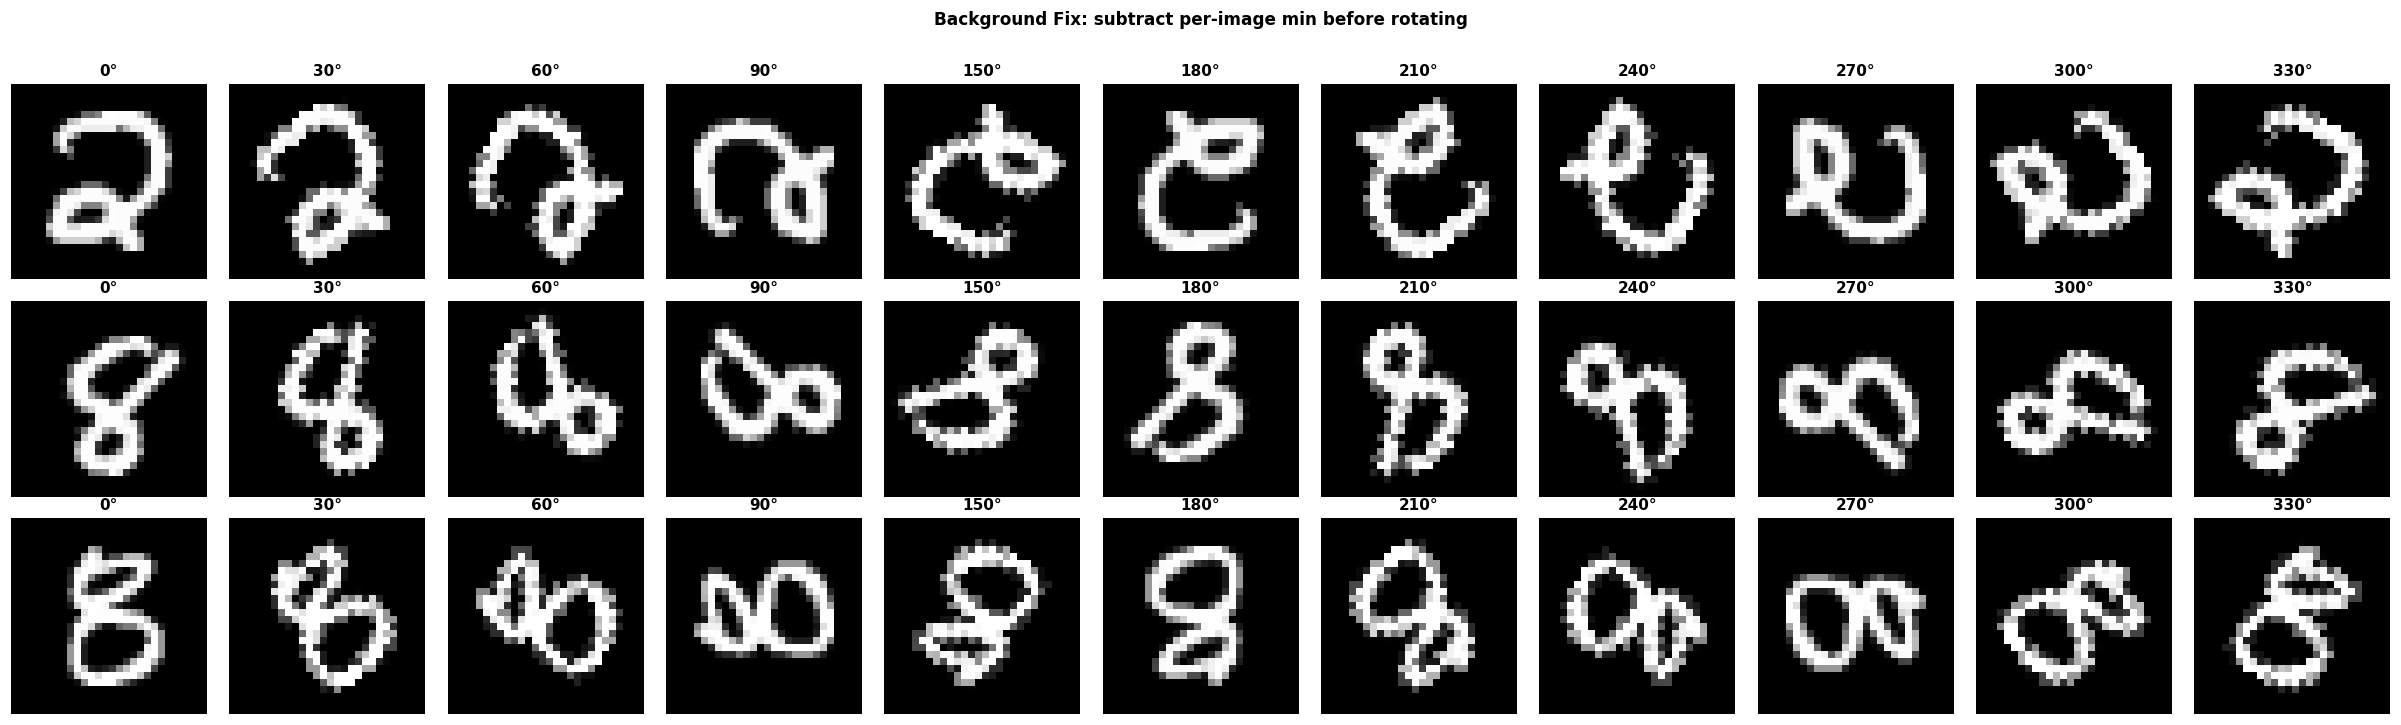

In [100]:
# ─── Rotation angles ──────────────────────────────────────────────────────────
ROTATION_ANGLES = [0, 15, 30, 45, 60, 90, 120, 150, 180]


def rotate_batch(x: torch.Tensor, angle: float) -> torch.Tensor:
    """
    Rotate images [N, C, H, W] by `angle` degrees.
    Background-preserving: subtract per-image min before rotate,
    add it back afterwards so new pixels match the image background.
    """
    if angle == 0:
        return x
    x_min     = x.flatten(1).min(dim=1).values.view(-1, 1, 1, 1)
    x_shifted = x - x_min          # background → 0
    rotated   = TF.rotate(x_shifted, angle, fill=0)
    return rotated + x_min          # restore background level


samples = X_test[0:3]   # [1, 1, 28, 28]
show_a = [0, 30, 60, 90, 150, 180, 210, 240, 270, 300, 330]

fig, axes = plt.subplots(len(samples), len(show_a), figsize=(len(show_a)*2.0, 6.5))
row_titles = ['Original', 'Naive (fill=0)\n→ bright border artefact',
               'Background-preserving\n→ correct background']

for i, sample in enumerate(samples):
    for col, angle in enumerate(show_a):
        fixed = rotate_batch(sample, angle).squeeze().numpy()
        axes[i, col].imshow(fixed, cmap='gray')
        axes[i, col].axis('off')
        axes[i, col].set_title(f'{angle}°', fontsize=10, fontweight='bold')

plt.suptitle('Rotated MNIST Examples',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9  Overconfidence Revealed — Baseline Under Rotation

We sweep the full test set over all rotation angles and track three quantities
for the **baseline softmax** classifier:

- **Accuracy** — does the model still predict correctly?
- **Mean max confidence** — does the model *think* it is still correct?
- **Predictive entropy** — does uncertainty rise to signal the OOD shift?

The **overconfidence gap** (confidence − accuracy) is the key diagnostic.
A model that stays 90% confident while becoming 50% accurate is
*dangerously miscalibrated* under distribution shift.

In [102]:
# ─── Rotation sweep helper ────────────────────────────────────────────────────
def rotation_sweep(predict_fn, X, y, angles=ROTATION_ANGLES):
    """
    predict_fn(X_rot) → (probs [N,10], entropy [N], mi [N])
    Returns dict with arrays for angle, acc, conf, entropy, mi.
    """
    y_labels = y.numpy() if isinstance(y, torch.Tensor) else y
    out = {k: [] for k in ['angle','acc','conf','entropy','mi']}
    for angle in angles:
        X_rot   = rotate_batch(X, angle)
        probs, ent, mi = predict_fn(X_rot)
        out['angle'].append(angle)
        out['acc'].append((probs.argmax(-1) == y_labels).mean())
        out['conf'].append(probs.max(-1).mean())
        out['entropy'].append(ent.mean())
        out['mi'].append(mi.mean())
    return {k: np.array(v) for k, v in out.items()}


def baseline_predict(X):
    p = get_probs(clf, X); return p, entropy(p), np.zeros(len(p))

print('Running baseline rotation sweep...')
base_rot = rotation_sweep(baseline_predict, X_test, y_test)
print('Done ✓')

Running baseline rotation sweep...
Done ✓


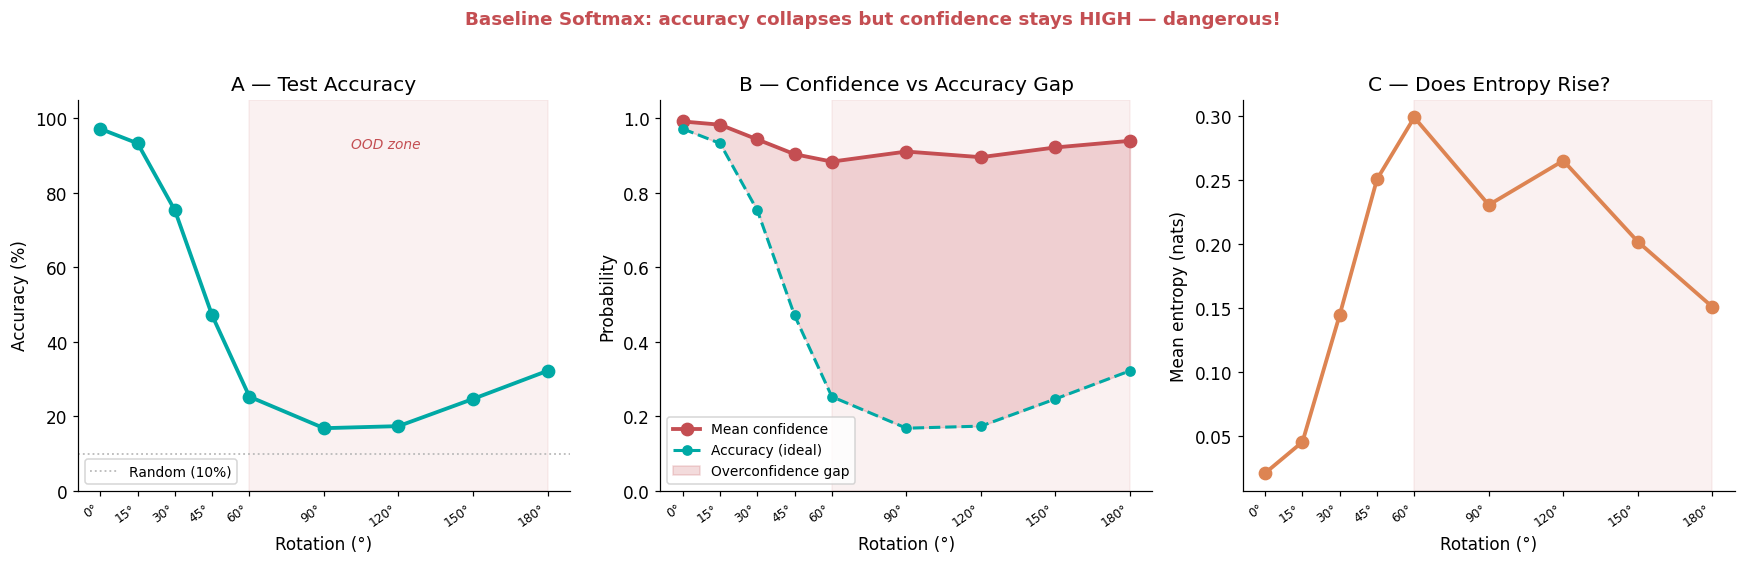

Overconfidence gap (conf − acc):
    0°  gap = +0.020  
   15°  gap = +0.050  ██
   30°  gap = +0.191  ████████
   45°  gap = +0.433  ███████████████████
   60°  gap = +0.631  ████████████████████████████
   90°  gap = +0.743  █████████████████████████████████
  120°  gap = +0.722  ████████████████████████████████
  150°  gap = +0.675  ██████████████████████████████
  180°  gap = +0.617  ███████████████████████████


In [104]:
# ─── The overconfidence story in three panels ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ang = base_rot['angle']

# A: accuracy
axes[0].plot(ang, base_rot['acc']*100, 'o-', color=TEAL, lw=2.5, ms=8)
axes[0].axhline(10, color=GRAY, ls=':', lw=1.2, label='Random (10%)')
axes[0].axvspan(60, 180, alpha=0.08, color=RED)
axes[0].set(xlabel='Rotation (°)', ylabel='Accuracy (%)',
             title='A — Test Accuracy', ylim=(0, 105))
axes[0].legend(fontsize=9)
axes[0].text(115, 92, 'OOD zone', ha='center', color=RED, fontsize=9, style='italic')

# B: the gap
axes[1].plot(ang, base_rot['conf'], 'o-',  color=RED,  lw=2.5, ms=8, label='Mean confidence')
axes[1].plot(ang, base_rot['acc'],  'o--', color=TEAL, lw=2.0, ms=6, label='Accuracy (ideal)')
axes[1].fill_between(ang, base_rot['acc'], base_rot['conf'],
                      where=base_rot['conf'] >= base_rot['acc'],
                      alpha=0.2, color=RED, label='Overconfidence gap')
axes[1].axvspan(60, 180, alpha=0.08, color=RED)
axes[1].set(xlabel='Rotation (°)', ylabel='Probability',
             title='B — Confidence vs Accuracy Gap', ylim=(0, 1.05))
axes[1].legend(fontsize=9)

# C: entropy
axes[2].plot(ang, base_rot['entropy'], 'o-', color=ORANGE, lw=2.5, ms=8)
axes[2].axvspan(60, 180, alpha=0.08, color=RED)
axes[2].set(xlabel='Rotation (°)', ylabel='Mean entropy (nats)',
             title='C — Does Entropy Rise?')

for ax in axes:
    ax.set_xticks(ang)
    ax.set_xticklabels([f'{a}°' for a in ang], rotation=35, ha='right', fontsize=8)

plt.suptitle('Baseline Softmax: accuracy collapses but confidence stays HIGH — dangerous!',
             fontsize=12, fontweight='bold', color=RED, y=1.02)
plt.tight_layout()
plt.show()

print('Overconfidence gap (conf − acc):')
for a, c, ac in zip(ang, base_rot['conf'], base_rot['acc']):
    g = c - ac
    print(f'  {a:>3}°  gap = {g:+.3f}  {chr(9608)*int(abs(g)*45)}')

---
## 10  All UQ Methods Under Rotation

Now we run the full rotation sweep for **all four methods** and compare
them on the same four metrics.

**What we expect to see:**
- All methods reach similar accuracy at 0° (same underlying CNN)
- MC Dropout and ensemble entropy should rise more steeply with rotation
- Mutual information (epistemic) should be the sharpest OOD signal

In [105]:
# ─── Run sweeps for MC Dropout and Ensemble ──────────────────────────────────
def mc_sweep(X):  return mc_predict(mc_clf, X, T=MC_T)
def ens_sweep(X): return ens_predict(X)

print('Running method sweeps...')
mc_rot  = rotation_sweep(mc_sweep,  X_test, y_test); print('  MC Dropout done')
ens_rot = rotation_sweep(ens_sweep, X_test, y_test); print('  Ensemble done')
print('All sweeps complete ✓')


Running method sweeps...
  MC Dropout done
  Ensemble done
All sweeps complete ✓


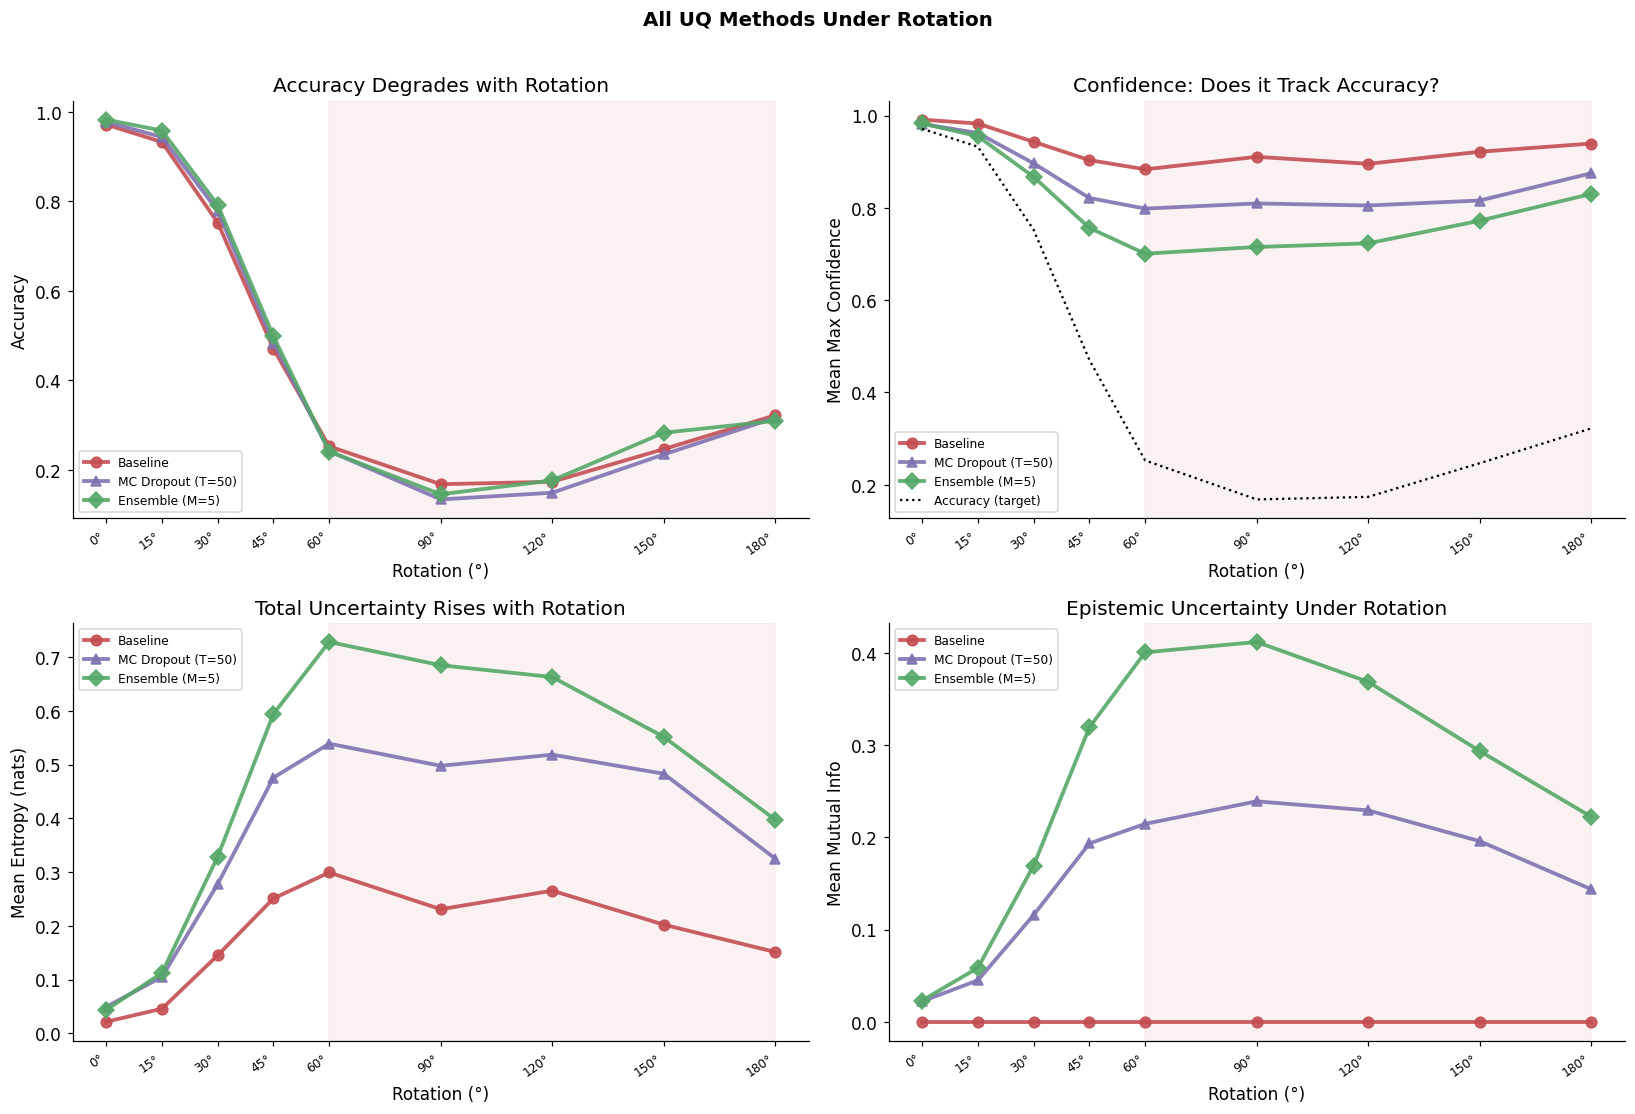

In [108]:
# ─── Four-panel comparison ───────────────────────────────────────────────────
method_styles = {
    'Baseline':               (base_rot, RED,    'o-',  2.5),
    f'MC Dropout (T={MC_T})': (mc_rot,   PURPLE, '^-',  2.5),
    f'Ensemble (M={N_ENS})':  (ens_rot,  GREEN,  'D-',  2.5),
}

panels = [
    ('acc',     'Accuracy',             'Accuracy Degrades with Rotation'),
    ('conf',    'Mean Max Confidence',  'Confidence: Does it Track Accuracy?'),
    ('entropy', 'Mean Entropy (nats)',  'Total Uncertainty Rises with Rotation'),
    ('mi',      'Mean Mutual Info',     'Epistemic Uncertainty Under Rotation'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, (key, ylabel, title) in zip(axes, panels):
    for name, (res, col, sty, lw) in method_styles.items():
        ax.plot(res['angle'], res[key], sty, color=col, lw=lw,
                 ms=7, alpha=0.9, label=name)
    if key == 'conf':
        ax.plot(base_rot['angle'], base_rot['acc'], 'k:', lw=1.5,
                 label='Accuracy (target)')
    ax.axvspan(60, 180, alpha=0.07, color=RED)
    ax.set(xlabel='Rotation (°)', ylabel=ylabel, title=title)
    ax.set_xticks(ROTATION_ANGLES)
    ax.set_xticklabels([f'{a}°' for a in ROTATION_ANGLES],
                        rotation=35, ha='right', fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('All UQ Methods Under Rotation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
